# Notebook: Precision — The Hidden Currency of Intelligence

This notebook generates the figures from the accompanying post and makes each mechanism directly manipulable. It is not self-contained - the post carries the argument; 

Three sections track the post in order: static Bayesian update, Kalman filter on a moving target, and emergent edge detectors from a sparse autoencoder. The appendix derives the steady-state Riccati equation for readers who want the math in full.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

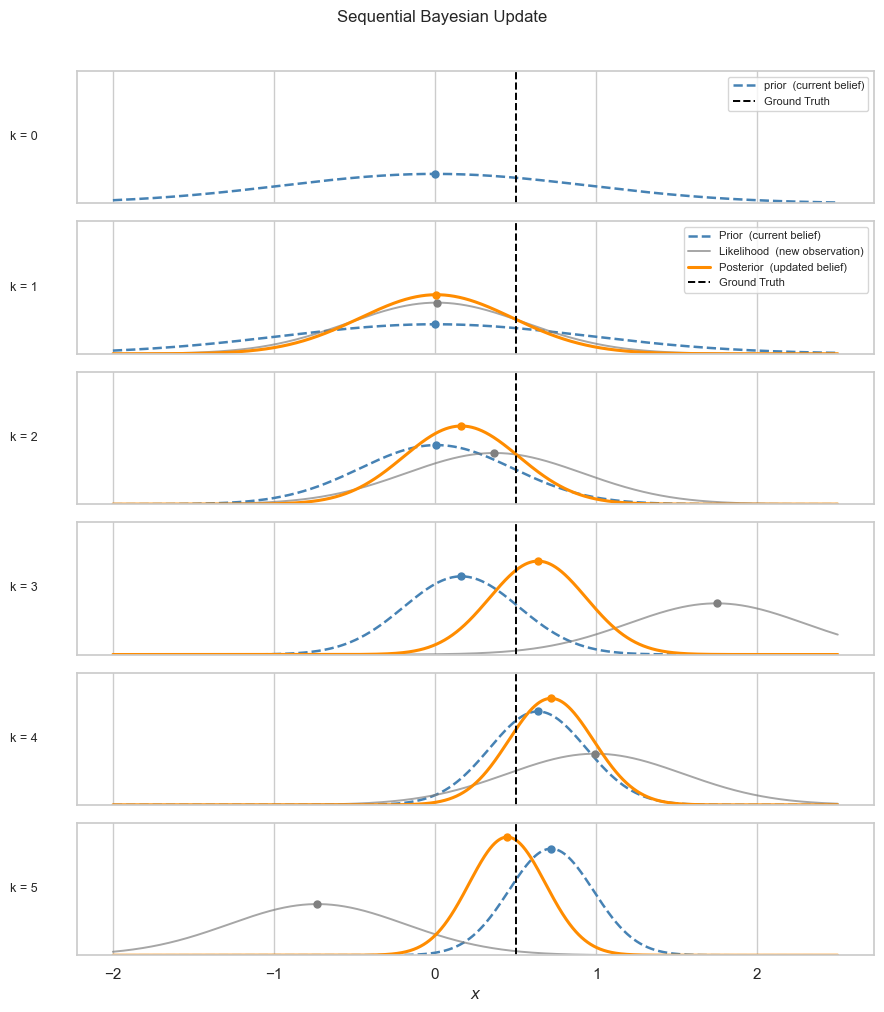

In [ ]:
# Baye's theorem perspective
mu_true    = 0.5    # ground truth
sigma_true = 0.75   # spread of observations around mu_true
P_obs      = 0.30   # measurement noise variance — higher = more interesting story

mu_prior   = 0.0    # initial belief
P_prior    = 0.90   # initial uncertainty (variance)

def gaussian(mu, P, x):
    return np.exp(-0.5 * (x - mu)**2 / P) / np.sqrt(2 * np.pi * P)

rng     = np.random.default_rng(seed=4)
obs     = rng.normal(mu_true, sigma_true, size=10)
x_space = np.linspace(-2.0, 2.5, 2000)

# Pre-compute all 5 posteriors
panels = []
P_history = [P_prior]  # initial prior variance, before any update

mp, pp = mu_prior, P_prior
for k in range(5):
    mu_k    = obs[k]
    mu_post = (mp * P_obs + mu_k * pp) / (pp + P_obs)
    P_post  = (pp * P_obs) / (pp + P_obs)

    panels.append((mp, pp, mu_k, mu_post, P_post))
    P_history.append(P_post)

    mp, pp  = mu_post, P_post

# Plot
fig, axes = plt.subplots(6, 1, figsize=(9, 10), sharex=True, sharey=True)

all_curves = []
for (mp, pp, mu_k, mu_post, P_post) in panels:
    all_curves += [gaussian(mp, pp, x_space),
                   gaussian(mu_k, P_obs, x_space),
                   gaussian(mu_post, P_post, x_space)]
y_max = max(c.max() for c in all_curves) * 1.12

# --- Panel 0: flat prior, no observation yet ---
ax = axes[0]
ax.plot(x_space, gaussian(mu_prior, P_prior, x_space),
        color='steelblue', lw=1.8, ls='--', label='prior  (current belief)')
ax.axvline(mu_true, color='black', lw=1.4, ls='--', label='Ground Truth')
mu_p_y = gaussian(mu_prior, P_prior, np.array([mu_prior]))[0]
ax.plot(mu_prior, mu_p_y, 'o', color='steelblue', ms=5, zorder=5)
ax.set_ylabel('k = 0', rotation=0, labelpad=38, va='center', fontsize=9)
ax.set_ylim(0, y_max)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

# --- Panels 1-5: sequential updates ---
for k, (mp, pp, mu_k, mu_post, P_post) in enumerate(panels):
    ax = axes[k + 1]

    ax.plot(x_space, gaussian(mp,      pp,    x_space), color='steelblue',  lw=1.8, ls='--',
            label='Prior  (current belief)'       if k == 0 else None)
    ax.plot(x_space, gaussian(mu_k,    P_obs, x_space), color='grey',        lw=1.4, alpha=0.7,
            label='Likelihood  (new observation)' if k == 0 else None)
    ax.plot(x_space, gaussian(mu_post, P_post, x_space), color='darkorange', lw=2.2,
            label='Posterior  (updated belief)'   if k == 0 else None)

    ax.axvline(mu_true, color='black', lw=1.4, ls='--',
               label='Ground Truth' if k == 0 else None)

    # mu markers
    for mu_val, P_val, color in [(mp, pp, 'steelblue'), (mu_k, P_obs, 'grey'), (mu_post, P_post, 'darkorange')]:
        y_val = gaussian(mu_val, P_val, np.array([mu_val]))[0]
        ax.plot(mu_val, y_val, 'o', color=color, ms=5, zorder=5)

    ax.set_ylabel(f'k = {k+1}', rotation=0, labelpad=38, va='center', fontsize=9)
    ax.set_ylim(0, y_max)
    ax.set_yticks([])

    if k == 0:
        ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

axes[-1].set_xlabel('$x$', fontsize=11)
fig.suptitle('Sequential Bayesian Update', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
fig.savefig("fig_sequential_bayesian_update.png", dpi=300, bbox_inches="tight")


The posterior from step $k$ becomes the prior for step $k+1$. Figure 2 extracts just the variance from this sequence — the qualitative narrowing above, now as a single number per step. Notice that the first observation does the most work; each subsequent one has less room to move you.

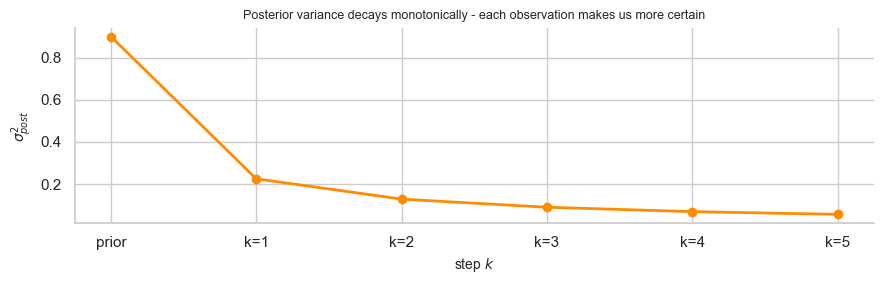

In [25]:
# --- Posterior variance decay ---
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(6), P_history, color='darkorange', lw=2, marker='o', ms=6)
ax.set_xlabel('step $k$', fontsize=10)
ax.set_ylabel('$\\sigma^2_{post}$', fontsize=10)
ax.set_title('Posterior variance decays monotonically - each observation makes us more certain',
             fontsize=9)
ax.set_xticks(range(6))
ax.set_xticklabels(['prior', 'k=1', 'k=2', 'k=3', 'k=4', 'k=5'])
sns.despine()
plt.tight_layout()
plt.show()
fig.savefig("fig_posterior_variance_decay.png", dpi=300, bbox_inches="tight")

## The Kalman Filter: Bayes in a Moving World

The static case above assumes the truth stays fixed. The Kalman filter is what happens when it doesn't.

The predict step carries the estimate forward in time, inflating $P$ by the process noise $Q$ - an honest admission that unobserved time costs certainty. The update step incorporates the new measurement, deflating $P$ in proportion to how reliable the sensor is. The Kalman gain $K_k$ is the ratio that mediates the two: when the model is uncertain relative to the sensor, it trusts the observation; when the sensor is noisy relative to the model, it trusts the prediction.

Three things are worth watching in the simulation below. Velocity is never measured directly — it is inferred from the pattern of position observations. $\text{tr}(P_k)$ settles at a non-zero floor, not zero: $Q$ ensures the filter maintains a baseline of healthy uncertainty at every step. And the sensor dropout at steps 15–18 makes the floor disappear — uncertainty climbs because the filter knows that unobserved time has a cost.

In [ ]:
# Kalman Filter implementation
dt = 1.0

A = np.array([[1, dt],
              [0,  1]])

C = np.array([[1, 0]])

Q = np.array([[0.5, 0.0],
              [0.0, 0.5]])

R = np.array([[5.0]])

rng    = np.random.default_rng(seed=7)
N      = 30
x_true = np.zeros((N, 2))
x_true[0] = [0.0, 1.0]

for k in range(1, N):
    w           = rng.multivariate_normal([0, 0], Q)
    x_true[k]   = A @ x_true[k-1] + w

z = x_true[:, 0:1] + rng.normal(0, np.sqrt(R[0, 0]), size=(N, 1))

# Bad prior — wrong position, uncertain
x_hat = np.array([5.0, 0.0])
P     = np.eye(2) * 10.0

I = np.eye(2)

estimates   = []
P_trace     = []
innovations = []
K_gains     = []   # track position component of K across time

BLINK_START = 15
BLINK_END   = 18  # exclusive

for k in range(N):
    # --- Predict ---
    x_hat_prior = A @ x_hat
    P_prior     = A @ P @ A.T + Q

    if BLINK_START <= k < BLINK_END:
        # Sensor offline — no update, uncertainty grows
        x_hat = x_hat_prior
        P     = P_prior
        innovations.append(None)
    else:
        # --- Innovation ---
        innovation  = z[k] - C @ x_hat_prior

        # --- Update ---
        S     = C @ P_prior @ C.T + R
        K     = P_prior @ C.T @ np.linalg.inv(S)
        x_hat = x_hat_prior + (K @ innovation).flatten()
        P     = (I - K @ C) @ P_prior

        innovations.append(float(innovation.flat[0]))

    estimates.append(x_hat.copy())
    P_trace.append(np.trace(P))
    K_gains.append(float(K[0].flat[0]))


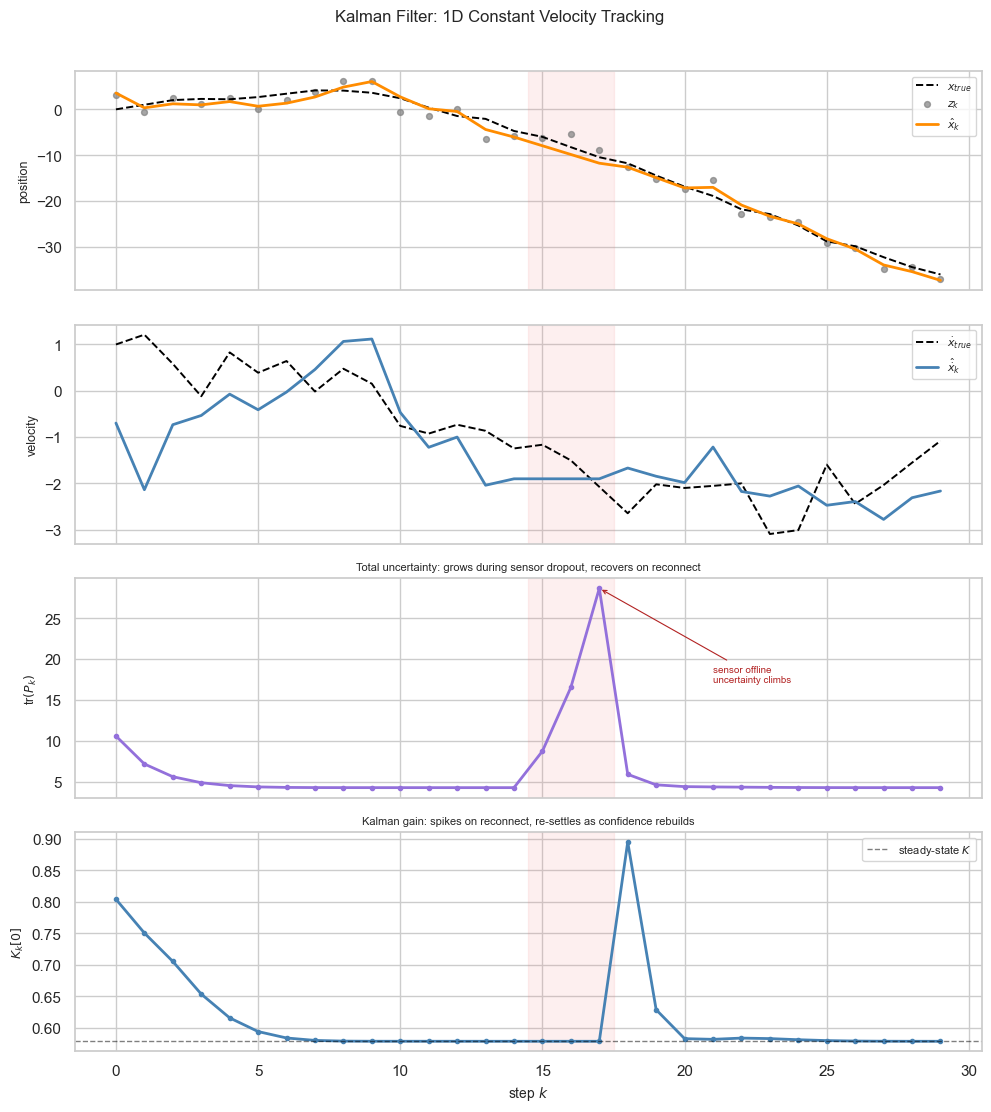

In [63]:
estimates = np.array(estimates)
steps     = np.arange(N)

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

# Shade blink window on all panels
for ax in axes:
    ax.axvspan(BLINK_START - 0.5, BLINK_END - 0.5, color='lightcoral', alpha=0.12, label='_nolegend_')

# Panel 1: position
axes[0].plot(steps, x_true[:, 0],    color='black',     lw=1.4, ls='--', label='$x_{true}$')
axes[0].scatter(steps, z[:, 0],      color='grey',      s=18,   alpha=0.7, label='$z_k$')
axes[0].plot(steps, estimates[:, 0], color='darkorange', lw=2.0, label='$\\hat{x}_k$')
axes[0].set_ylabel('position', fontsize=9)
axes[0].legend(loc='upper right', fontsize=8, framealpha=0.8)

# Panel 2: velocity
axes[1].plot(steps, x_true[:, 1],    color='black',     lw=1.4, ls='--', label='$\\dot{x}_{true}$')
axes[1].plot(steps, estimates[:, 1], color='steelblue', lw=2.0, label='$\\hat{\\dot{x}}_k$')
axes[1].set_ylabel('velocity', fontsize=9)
axes[1].legend(loc='upper right', fontsize=8, framealpha=0.8)

# Panel 3: trace of P
axes[2].plot(steps, P_trace, color='mediumpurple', lw=2.0, marker='o', ms=3)
axes[2].set_ylabel('tr$(P_k)$', fontsize=9)
axes[2].annotate('sensor offline\nuncertainty climbs',
                 xy=(17, max(P_trace[BLINK_START:BLINK_END])),
                 xytext=(21, max(P_trace[BLINK_START:BLINK_END]) * 0.6),
                 fontsize=7, color='firebrick',
                 arrowprops=dict(arrowstyle='->', color='firebrick', lw=0.8))
axes[2].set_title('Total uncertainty: grows during sensor dropout, recovers on reconnect', fontsize=8)

# Panel 4: Kalman gain
valid_K = [k for k in K_gains if k is not None]
axes[3].plot(steps, K_gains, color='steelblue', lw=2.0, marker='o', ms=3)
axes[3].axhline(np.mean(K_gains[-5:]), color='black', lw=1.0, ls='--', alpha=0.5,
                label='steady-state $K$')
axes[3].set_ylabel('$K_k[0]$', fontsize=9)
axes[3].set_xlabel('step $k$', fontsize=10)
axes[3].set_title('Kalman gain: spikes on reconnect, re-settles as confidence rebuilds', fontsize=8)
axes[3].legend(fontsize=8, framealpha=0.8)

plt.suptitle('Kalman Filter: 1D Constant Velocity Tracking', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig_kalman_update.png", dpi=300, bbox_inches="tight")
plt.show()

## Emergent Representations: Sparse Autoencoders

The model below has no biological prior. It sees image patches, reconstructs them, and is penalized for using more than $k$ active units at a time. That pressure — reconstruct well, use few neurons — is the only constraint.

The question is what the encoder learns under it. The filters that emerge are worth comparing to what the post describes evolution and predictive coding arriving at independently.

Loading CIFAR-10...
Files already downloaded and verified
Applying ZCA whitening...
Patches: (200000, 64)
epoch   1 | loss 0.70638 | dead 0/1024
epoch  10 | loss 0.36221 | dead 0/1024
epoch  20 | loss 0.29632 | dead 54/1024
epoch  30 | loss 0.28057 | dead 363/1024
epoch  40 | loss 0.27590 | dead 485/1024
epoch  50 | loss 0.27287 | dead 566/1024
epoch  60 | loss 0.27169 | dead 538/1024
epoch  70 | loss 0.27056 | dead 546/1024
epoch  80 | loss 0.26988 | dead 520/1024
epoch  90 | loss 0.26921 | dead 534/1024
epoch 100 | loss 0.26886 | dead 554/1024


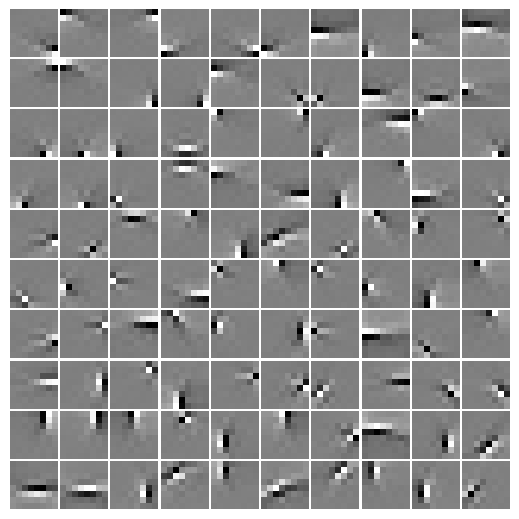

In [ ]:
# Sparse Autoencoder (Edge Detector Emergence)


# ── Data: Extract and whiten image patches ────────────────────────────────────
def get_cifar_patches(patch_size=8, n_patches=200000, seed=42):
    """
    1. Load CIFAR-10 (grayscale)
    2. Sample random patches
    3. Normalize + ZCA whiten

    Whitening is critical: it removes pixel correlations so that
    the model is forced to learn *structure* (edges), not redundancy.
    """
    try:
        import torchvision, torchvision.transforms as T
        print("Loading CIFAR-10...")
        ds = torchvision.datasets.CIFAR10(
            root="/tmp/cifar",
            train=True,
            download=True,
            transform=T.Grayscale()
        )
        images = np.stack([np.array(ds[i][0]) for i in range(len(ds))]).astype(np.float32) / 255.0
    except Exception as e:
        print(f"Fallback dataset ({e})")
        from sklearn.datasets import load_sample_images
        images = np.stack([img.mean(-1).astype(np.float32)/255. for img in load_sample_images().images])

    rng = np.random.default_rng(seed)
    H, W = images[0].shape

    patches = []
    per_img = max(1, n_patches // len(images))

    for img in images:
        for _ in range(per_img):
            r = rng.integers(0, H - patch_size)
            c = rng.integers(0, W - patch_size)
            patches.append(img[r:r+patch_size, c:c+patch_size].ravel())
        if len(patches) >= n_patches:
            break

    data = np.array(patches[:n_patches], dtype=np.float32)
    data -= data.mean(axis=1, keepdims=True)

    data -= data.mean(axis=0, keepdims=True)

    print("Applying ZCA whitening...")
    cov = np.cov(data, rowvar=False)

    U, S, _ = np.linalg.svd(cov)

    # Small epsilon preserves high-frequency detail (edges)
    eps = 1e-5
    W_zca = (U @ np.diag(1.0 / np.sqrt(S + eps)) @ U.T).astype(np.float32)

    data = data @ W_zca
    data /= data.std() + 1e-8

    print(f"Patches: {data.shape}")
    return torch.from_numpy(data)


# ── Model: k-Sparse Autoencoder ───────────────────────────────────────────────
class KSparseAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, k):
        super().__init__()

        self.k = k
        self.hidden_dim = hidden_dim

        # Encoder learns dictionary atoms
        self.encoder = nn.Linear(input_dim, hidden_dim, bias=True)
        nn.init.xavier_uniform_(self.encoder.weight)
        nn.init.constant_(self.encoder.bias, 0.0)

        # Tie decoder weights to encoder transpose - This enforces proper sparse coding structure
        self.decoder = nn.Linear(hidden_dim, input_dim, bias=False)
        self.decoder.weight = nn.Parameter(self.encoder.weight.t())

        # Track how often each neuron fires (for dead neuron prevention)
        self.register_buffer("firing_rate", torch.ones(hidden_dim) / hidden_dim)
        self.ema_decay = 0.99

    def forward(self, x, use_boost=True):
        # Linear encoding
        z = self.encoder(x)

        if use_boost:
            # Encourage underused neurons to participate
            target_rate = self.k / self.hidden_dim
            boost = torch.clamp(target_rate - self.firing_rate, min=0)

            # Gentle boost (too large destroys competition)
            z = z + boost.unsqueeze(0) * 5.0

        # Keep only top-k activations (hard sparsity)
        topk_vals, topk_idx = torch.topk(z, self.k, dim=1)

        h = torch.zeros_like(z)

        # Note: no ReLU = allow positive and negative responses
        h.scatter_(1, topk_idx, topk_vals)

        # Update firing statistics
        if self.training:
            fired = (h != 0).float().mean(dim=0)
            self.firing_rate = self.ema_decay * self.firing_rate + (1 - self.ema_decay) * fired

        # Decode (reconstruct input)
        return self.decoder(h), h

    def normalize_weights(self):
        """
        Normalize encoder rows (dictionary atoms)
        Prevents runaway scaling and stabilizes training.
        """
        with torch.no_grad():
            self.encoder.weight.data /= self.encoder.weight.data.norm(dim=1, keepdim=True).clamp(min=1e-8)


# ── Training ─────────────────────────────────────────────────────────────────
def train(model, data, epochs=100, batch_size=256, lr=1e-3):
    """
    Train using reconstruction loss.
    No explicit sparsity loss — sparsity enforced by top-k selection.
    """
    opt = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    n = len(data)

    for epoch in range(epochs):
        idx = torch.randperm(n)
        total_loss = 0.0
        n_batches = 0

        for i in range(0, n, batch_size):
            x = data[idx[i:i+batch_size]]

            recon, _ = model(x, use_boost=True)

            loss = ((x - recon) ** 2).mean()

            opt.zero_grad()
            loss.backward()
            opt.step()

            model.normalize_weights()

            total_loss += loss.item()
            n_batches += 1

        scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            target = model.k / model.hidden_dim
            dead = (model.firing_rate < target * 0.01).sum().item()

            print(f"epoch {epoch+1:3d} | loss {total_loss/n_batches:.5f} | dead {dead}/{model.hidden_dim}")

    return model


# ── Visualization ─────────────────────────────────────────────────────────────
def plot_filters(model, patch_size=8, n_show=100):
    W = model.encoder.weight.detach().cpu().numpy()
    rates = model.firing_rate.cpu().numpy()
    top_idx = np.argsort(rates)[::-1][:n_show]

    grid = int(np.sqrt(n_show))
    
    # Reduced figsize for better blog embedding
    fig, axes = plt.subplots(grid, grid, figsize=(5, 5), facecolor="white")

    for i, ax in enumerate(axes.flat):
        if i < len(top_idx):
            idx = top_idx[i]
            patch = W[idx].reshape(patch_size, patch_size)
            vmax = np.abs(patch).max() + 1e-8
            ax.imshow(patch, cmap="gray", vmin=-vmax, vmax=vmax)
        
        ax.axis("off")

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)
    plt.savefig("fig_sparse.png", dpi=150, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
PATCH_SIZE = 8          # Smaller patches = cleaner local edges
HIDDEN_DIM = 1024
K = 10                  # Strong sparsity (~1%)

data = get_cifar_patches(patch_size=PATCH_SIZE, n_patches=200000)

model = KSparseAE(
    input_dim=PATCH_SIZE**2,
    hidden_dim=HIDDEN_DIM,
    k=K
)

model = train(model, data, epochs=100, batch_size=256, lr=1e-3)

plot_filters(model, patch_size=PATCH_SIZE, n_show=100);


## Appendix: The Steady-State of Uncertainty

### Deriving the Discrete Algebraic Riccati Equation (DARE)

The Riccati equation is the Kalman filter run to equilibrium. If noise parameters $Q$ and $R$ are held constant, $P$ eventually stops changing. Let $P_\infty$ be that fixed point. At steady state:

1. **Predict:** $P_{k}^- = A P_{\infty} A^T + Q$  
2. **Update:** $P_{\infty} = (I - K_\infty C)\, P_{k}^-$

Where the steady-state gain is:
$$K_\infty = P_{k}^- C^T \left(C P_{k}^- C^T + R\right)^{-1}$$

Substituting into the update equation gives the DARE:

$$P_\infty = A P_\infty A^T + Q - A P_\infty C^T \left(C P_\infty C^T + R\right)^{-1} C P_\infty A^T$$

The positive term is the spreading of belief due to dynamics and process noise. The negative term is the sharpening due to measurement. At $P_\infty$ they balance exactly — the filter has reached its terminal uncertainty. No additional data can reduce it further, because the world is moving as fast as the sensor can correct.